# Customer Segmentation using K-Means Clustering
### Eyda Duran  
Capstone Project – Postgraduate Diploma in AI & Machine Learning  

---

## Objective
To segment customers based on income and spending behavior using K-Means clustering and generate actionable insights to support data-driven business decision-making.

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/eyda-ai/customer-segmentation-capstone/main/Mall_Customers.csv"
df = pd.read_csv(url)

df.head()



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              20 non-null     int64 
 1   Gender                  20 non-null     object
 2   Age                     20 non-null     int64 
 3   Annual Income (k$)      20 non-null     int64 
 4   Spending Score (1-100)  20 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 932.0+ bytes


## Data Exploration

In this section, we explore the dataset to understand its structure, key variables, and statistical properties. This helps prepare the data for clustering.
The dataset contains customer demographic and behavioral features such as age, income, and spending score.

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,20.00000,20.000000,20.000000,20.000000
mean,10.50000,33.650000,18.800000,50.950000
std,5.91608,15.114563,2.330575,34.149016
min,1.00000,19.000000,15.000000,3.000000
25%,5.75000,22.000000,17.000000,14.750000
50%,10.50000,30.500000,19.000000,53.000000
75%,15.25000,35.500000,20.000000,77.500000
max,20.00000,67.000000,23.000000,99.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

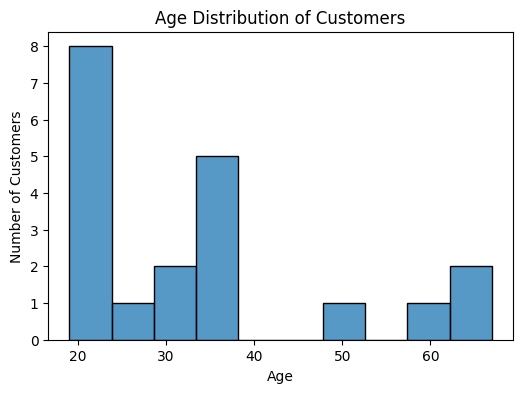

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=10)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

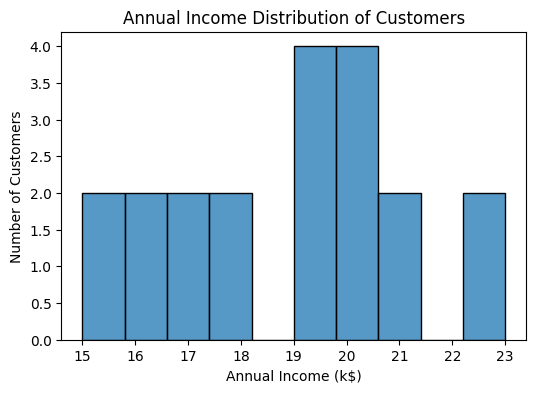

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=10)

plt.title("Annual Income Distribution of Customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

## K-Means Clustering

In this section, we apply K-Means clustering to segment customers based on their annual income and spending score. The goal is to identify distinct customer groups with similar purchasing behavior.

## Final K-Means Model

In this step, we apply K-Means clustering using the optimal number of clusters identified from the Elbow Method (K = 5). The model assigns each customer to a cluster based on their income and spending behavior.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels
df['Cluster'] = y_kmeans

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,4
2,3,Female,20,16,6,2
3,4,Female,23,16,77,4
4,5,Female,31,17,40,2


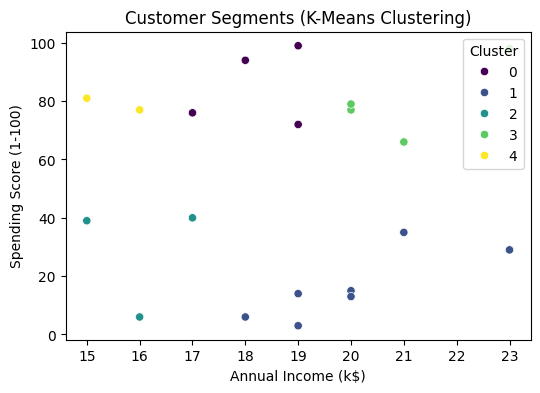

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    data=df
)

plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.show()

## Cluster Insights & Business Interpretation

Based on the K-Means clustering results, customers can be grouped into distinct segments:

- **Cluster 0:** High spending score customers with moderate income — potential loyal or premium customers.
- **Cluster 1:** Low spending score customers — may require targeted promotions to increase engagement.
- **Cluster 2:** Moderate spending and income — average customers with stable purchasing behavior.
- **Cluster 3:** High income but lower spending — opportunity for upselling and personalized marketing.
- **Cluster 4:** Low income but high spending — impulsive buyers or discount-driven customers.

### Business Recommendation:
Companies can use these segments to:
- Design targeted marketing campaigns
- Improve customer retention strategies
- Increase revenue through personalized offers

In [ ]:
from sklearn.cluster import KMeans

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

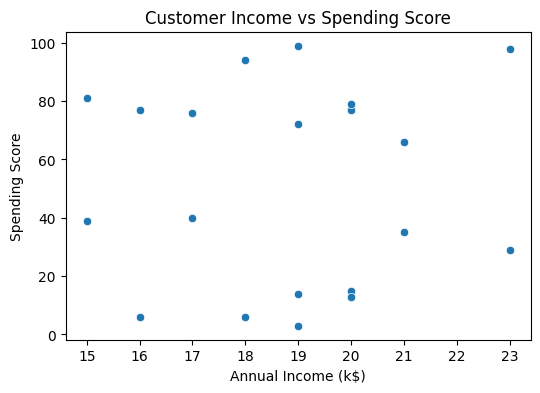

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)

plt.title("Customer Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

In [ ]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.99444379, -1.67285672, -0.35902766],
       [-0.85868355, -1.67285672,  0.90282689],
       [-0.92656367, -1.23263127, -1.35048481],
       [-0.7229233 , -1.23263127,  0.78265027],
       [-0.17988232, -0.79240582, -0.32898351]])

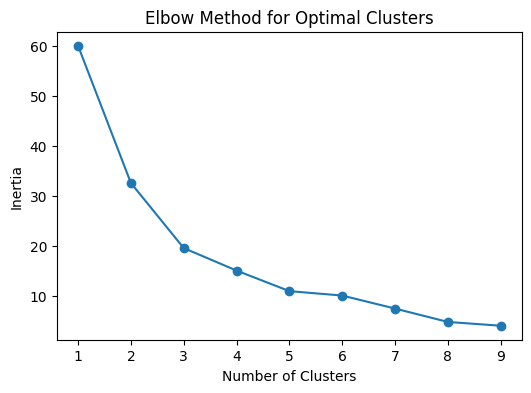

In [ ]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(1,10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

## Elbow Method
To determine the optimal number of clusters, we use the Elbow Method.
This technique evaluates the Within-Cluster Sum of Squares (WCSS) for different values of K.
The optimal K is identified where the decrease in WCSS begins to slow down, forming an "elbow" shape.

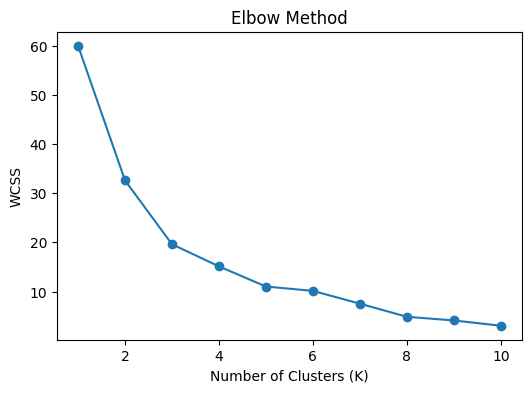

In [ ]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

plt.show()

Based on the Elbow Method, the optimal number of clusters is K = 5, where the rate of decrease in WCSS starts to level off. This value is used for the final K-Means clustering model.

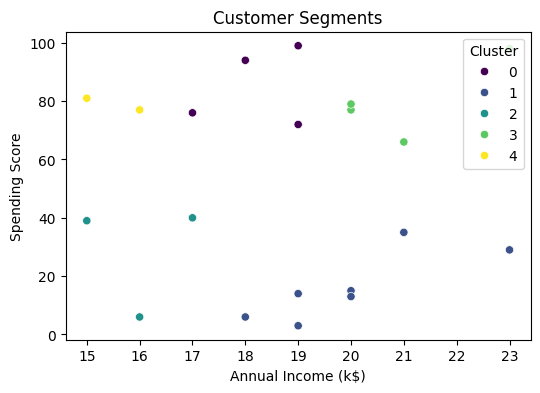

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()